# Предсказание возрастной категории пользователей по цифровому следу

### Цель и задачи

Компания **"Йети"** использует демографический таргетинг в рекламной сети и хочет автоматически определять возрастную категорию пользователей по их активности в интернете. Это необходимо для повышения эффективности рекламных кампаний и снижения рисков некорректного показа рекламы (в том числе для несовершеннолетних).
   - Цель: построить модель машинного обучения, которая по цифровому следу пользователя предсказывает целевую переменную `age_category` - возрастную категорию.
   - Задачи:
     1. Тип задачи: многоклассовая классификация.
	 2. Целевая переменная: `age_category` (5 классов):
	    - 0: младше 18
	    - 1: 18–25
	    - 2: 26–40
	    - 3: 41–55
	    - 4: 56+
	 3.	Подготовить единую витрину признаков из нескольких источников:
	    - агрегаты активности из логов посещений сайтов (`visits`),
	    - дополнительные признаки поведения и профиля устройства (`ads_activity`, `surf_depth`, `primary_device`, `cloud_usage`).
	 4.	Корректно организовать обучение без утечек данных: вся предобработка выполняется внутри `Pipeline`/`ColumnTransformer`.
	 5.	Обучить и сравнить несколько архитектур:
        - `DummyClassifier` как **baseline**,
        - `LogisticRegression`,
        - `SVC`с разными ядрами (в т.ч. `linear`, `rbf`),
        - подобрать гиперпараметры с помощью `GridSearchCV`.
	 6.	Оценивать качество одинаково по всем классам:
        - основная метрика - `F1_macro`,
        - дополнительные - `precision_macro`, `recall_macro`.
	 7.	Требование к качеству: `F1_macro` >= 0.75 и на кросс-валидации по `train`, и на тестовой выборке.
	 8.	Подготовка к внедрению:
        - сохранить полный пайплайн (предобработка + модель) с помощью `joblib`,
        - проверить воспроизводимость предсказаний после загрузки артефакта.

---------------

### Данные

- Данные представлены в нескольких **CSV-файлах**, полученных из разных источников:
    - `ds_s13_users.csv` - целевая переменная:
    - `user_id`, `age_category`
    - `ds_s13_visits.csv` - лог посещений:
    - `date`, `daytime` (утро/день/вечер/ночь), `session_id`, `user_id`, `website_category`
    - `ads_activity.csv` - частота взаимодействия с рекламой (CTR-активность):
    - `user_id`, `ads_activity` (очень редко ... очень часто)
    - `surf_depth.csv` - глубина просмотра в сессии:
    - `user_id`, `surf_depth` (поверхностно/средне/глубоко)
    - `primary_device.csv` - основное устройство:
    - `user_id`, `primary_device`
    - `cloud_usage.csv` - использование облачных сервисов:
    - `user_id`, `cloud_usage` (True/False)

--------------

### Особенности данных и требования к обучению
- таблицы имеют разную полноту покрытия пользователей -> возможны пропуски после объединения;
- признаки в `visits` представлены на уровне событий, поэтому требуется агрегация на пользователя (доли активности по категориям/времени суток, агрегаты сессий);
- при разбиении на выборки важно, чтобы один пользователь не оказался и в `train`, и в `test` (в проекте витрина строится на уровне пользователя, 1 строка = 1 пользователь);
- фиксируется `RANDOM_STATE` и используется стратификация по `age_category` в разбиении и кросс-валидации.

-----------------

### Структура проекта
1.	Загрузка данных и первичное знакомство с таблицами.
2.	EDA: анализ распределений целевой переменной и признаков, пропусков, дубликатов, первичные выводы.
3.	Сбор витрины признаков (`feature engineering` из `visits` и объединение источников в единый датасет).
4.	Предобработка: разбиение на `train`/`test`, сборка `Pipeline` + `ColumnTransformer` (импутация, `OHE`, масштабирование).
5.	Обучение и оценка **baseline-моделей** (`Dummy`, `LogisticRegression`, `SVC`) на кросс-валидации.
6.	Создание и отбор признаков (фильтрация/обёртки) и сравнение конфигураций по `CV`.
7.	Подбор гиперпараметров (`GridSearchCV`) для `LogisticRegression` и `SVC`.
8.	Финальная модель: обучение на `train`, оценка на `test`, анализ ошибок.
9.	Сохранение артефактов (`joblib`) и проверка корректности загрузки/предсказаний.

## 1. Подготовка среды и библиотек

In [1]:
# =========================
# Imports & environment
# =========================
import os
import sys
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.special import expit

# Установка доп. пакетов
!{sys.executable} -m pip -q install -U category-encoders phik

# =========================
# Scikit-learn: model selection
# =========================
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

# =========================
# Scikit-learn: preprocessing & pipelines
# =========================
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer

# =========================
# Scikit-learn: feature selection
# =========================
from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif,
    RFE,
    RFECV
)

# =========================
# Scikit-learn: models
# =========================
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC

# =========================
# Scikit-learn: metrics
# =========================
from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# =========================
# Encoders & correlation analysis
# =========================
from category_encoders.target_encoder import TargetEncoder
from phik import phik_matrix
from phik.report import plot_correlation_matrix

In [2]:
# сохраняем полный список пакетов окружения
!{sys.executable} -m pip freeze > requirements.txt

print("requirements.txt создан/обновлён из текущего окружения")

In [3]:
# Задаём константы
TEST_SIZE = 0.2
RANDOM_STATE = 42
N_SPLITS = 5 # для CV

In [4]:
# Настройка отображения
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:.4f}".format)

In [5]:
# Загрузка датасетов под проект
def load_csv(filename):
    try:
        return pd.read_csv(f"/datasets/{filename}") # Платформа
    except:
        return pd.read_csv(f"data/{filename}") # Локально

users = load_csv("ds_s13_users.csv")
visits = load_csv("ds_s13_visits.csv")
ads_activity = load_csv("ads_activity.csv")
surf_depth = load_csv("surf_depth.csv")
primary_device = load_csv("primary_device.csv")
cloud_usage = load_csv("cloud_usage.csv")

for name, df in [
    ("users", users), ("visits", visits), ("ads_activity", ads_activity),
    ("surf_depth", surf_depth), ("primary_device", primary_device),
    ("cloud_usage", cloud_usage),
]:
    print(name, df.shape)

In [6]:
for name, df in [
    ("users", users), ("visits", visits), ("ads_activity", ads_activity),
    ("surf_depth", surf_depth), ("primary_device", primary_device),
    ("cloud_usage", cloud_usage),
]:
    print(name)
    df.info()
    print()

In [7]:
# проверка уникальности пользователя в users
users['user_id'].is_unique

Загуржены данные и библиотеки, так же установленны константы.
По загруженным данным мы видим:
 - `users` ~ 6k строк, однако есть дубликаты в пользователях.
 - `ads_activity` / `surf_depth` / `primary_device` / `cloud_usage` тоже ~ 1 строка на пользователя (или почти на каждого).
 - `visits` 1+ млн строк = лог событий: 1 строка = 1 сессия/посещение. Один пользователь делает много сессий -> поэтому строк в разы больше.

## 2. EDA (Исследовательский анализ данных)
1. Исследуем `users`/`ads_activity` / `surf_depth` / `primary_device` / `cloud_usage`/`visits`:
    - проверяем на дубликаты
    - проверяем на наличие пропусков
    - исследуем распределение целевой переменной (с визуализациями)
    - исследуем числовые и категориальные признаки (с визуализациями)
2. Изучаем корреляцию между признаками

#### Исследуем users

In [8]:
# Исследуем дубликаты в таблице users
dups = users['user_id'].duplicated().sum()
print(dups)

In [9]:
dups = users[users["user_id"].duplicated(keep=False)].sort_values("user_id")
dups.head(20)

In [10]:
# Проверка на конфликты
conflicts = (users.groupby("user_id")["age_category"]
             .nunique()
             .sort_values(ascending=False))

conflicts[conflicts > 1].head(20)

In [11]:
# Удаление дубликатов
users = users.drop_duplicates(subset='user_id').reset_index(drop=True)
users["user_id"].is_unique

В таблице users обнаружены дубликаты по `user_id` (87). Проверка показала, что во всех дублях целевой класс `age_category` совпадает (конфликтов нет). Для корректного сплита по пользователям и объединения данных удалили дубликаты, оставив по одной записи на пользователя.

In [12]:
# изучаем распределение целевой переменной:
target_dist = (
    users['age_category']
    .value_counts()
    .sort_index()
    .to_frame('count')
)
target_dist['share'] = (target_dist['count'] / target_dist['count'].sum()).round(4)

age_map = {
    0: "<18",
    1: "18–25",
    2: "26–40",
    3: "41–55",
    4: "56+"
}

target_dist = target_dist.rename(index=age_map)
target_dist

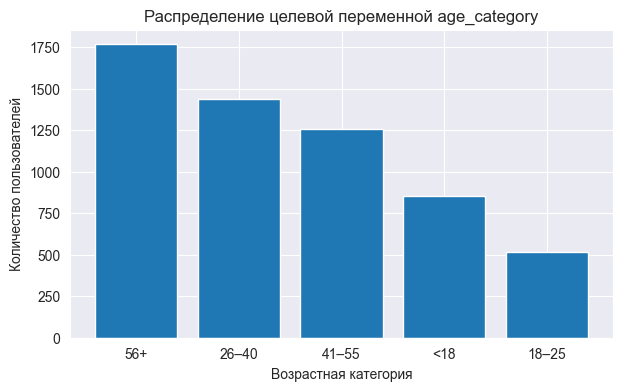

In [13]:
# визуализируем распределение целевой переменной
counts = users["age_category"].value_counts()
labels = [age_map[i] for i in counts.index]

plt.figure(figsize=(7, 4))
plt.bar(labels, counts.values)
plt.title("Распределение целевой переменной age_category")
plt.xlabel("Возрастная категория")
plt.ylabel("Количество пользователей")
plt.xticks(rotation=0)
plt.show()

Целевая переменная распределена неравномерно: крупнейший класс 56+ (30%), наименьший 18–25 (9%). В связи с дисбалансом классов для оценки качества будем использовать метрики с макро-усреднением (`F1_macro`, `precision_macro`, `recall_macro`), чтобы модель была одинаково "внимательна" ко всем возрастным группам.


In [14]:
# оптимизация размерности целевой переменной
users["age_category"] = users["age_category"].astype("int8")
users.dtypes

Поскольку целевая переменная содержит всего 5 категорий, привели тип `age_category` к `int8` для экономии памяти.

#### Исследуем `ads_activity`

In [15]:
# Исследуем распределение уникальных значений
ads_activity['ads_activity'].value_counts()

В таблице `ads_activity` 5 уникальных значений с явным дисбалансом, в наибольшем **умеренно** 1897 а в наименьшем **очень часто** 238

In [16]:
# Вывод явных дубликатов
ads_activity['user_id'].duplicated().sum()

Явных дубликатов 233

In [17]:
# Проверка на конфликты
conflicts = (ads_activity.groupby("user_id")["ads_activity"]
             .nunique()
             .sort_values(ascending=False))

conflicts[conflicts > 1].head(20)

конфликтов не обнаруженно

In [18]:
# Удаляем дубли ads_activity
ads_activity = ads_activity.drop_duplicates(subset='user_id').reset_index(drop=True)
ads_activity['user_id'].is_unique

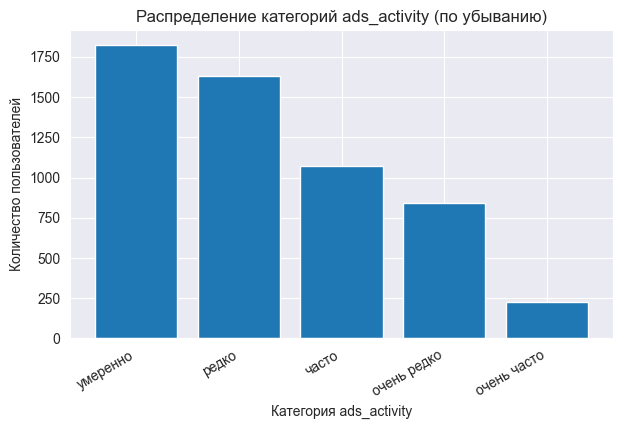

In [19]:
# изучаем распределение характеристик CTR:
ads_dist = (
    ads_activity['ads_activity']
    .value_counts()
    .to_frame('count')
)
ads_dist['share'] = (ads_dist['count'] / ads_dist['count'].sum()).round(4)
display(ads_dist)

counts = ads_activity["ads_activity"].value_counts()

plt.figure(figsize=(7,4))
plt.bar(counts.index, counts.values)
plt.title("Распределение категорий ads_activity (по убыванию)")
plt.xlabel("Категория ads_activity")
plt.ylabel("Количество пользователей")
plt.xticks(rotation=30, ha="right")
plt.show()

In [20]:
# Смотрим долю пользователй у которых есть ads_activity
coverage = users["user_id"].isin(ads_activity["user_id"]).mean()
print(f"Доля пользователей с ads_activity: {coverage:.2%}")

Признак `ads_activity` имеет 5 категорий и распределён неравномерно. Наиболее частые значения — "умеренно" (32.6%) и "редко" (29.2%). Самая редкая категория — "очень часто" (~4.0%). `ads_activity` доступен для 96% пользователей, для оставшихся 4% значение отсутствует и будет обработано при предобработке (импутация/отдельная категория).


## Исследуем `surf_depth`, `primary_device`, `cloud_usage`

In [21]:
# Проверяем уникальность значаений
print(surf_depth['user_id'].is_unique)
print(primary_device['user_id'].is_unique)
print(cloud_usage['user_id'].is_unique)

In [22]:
print(surf_depth.columns)
print(surf_depth['user_id'].duplicated().sum())
print(surf_depth['surf_depth'].value_counts())

In [23]:
print(primary_device.columns)
print(primary_device['user_id'].duplicated().sum())
print(primary_device['primary_device'].value_counts())

In [24]:
print(cloud_usage.columns)
print(cloud_usage['user_id'].duplicated().sum())
print(cloud_usage['cloud_usage'].value_counts())

In [25]:
def coverage(df, name):
    cov = users['user_id'].isin(df['user_id']).mean()
    miss = (~users['user_id'].isin(df['user_id'])).sum()
    print(f"{name:>15}: coverage={cov:.2%}, missing_users={miss}")

coverage(surf_depth, "surf_depth")
coverage(primary_device, "primary_device")
coverage(cloud_usage, "cloud_usage")

Дополнительные таблицы покрывают большую часть пользователей: `surf_depth` - 98.1%, `primary_device` - 97.3%, `cloud_usage` - 97.5%. Для оставшихся пользователей значения отсутствуют, поэтому при объединении витрины появятся пропуски, которые будут обработаны на этапе предобработки (импутация/выделение категории "unknown").


In [26]:
# Задаём функцию для визуализации распределния признаков
def plot_cat_dist(df, col, title=None, top_n=None, order=None, rotation=30):
    counts = df[col].value_counts()  # по убыванию

    if order is not None:
        counts = counts.reindex(order)
    if top_n is not None:
        counts = counts.head(top_n)

    dist = counts.to_frame("count")
    dist["share"] = (dist["count"] / dist["count"].sum()).round(4)
    display(dist)

    plt.figure(figsize=(8, 4))
    plt.bar(dist.index.astype(str), dist["count"].values)
    plt.title(title if title else f"Распределение {col}")
    plt.xlabel(col)
    plt.ylabel("Количество пользователей")
    plt.xticks(rotation=rotation, ha="right")
    plt.show()

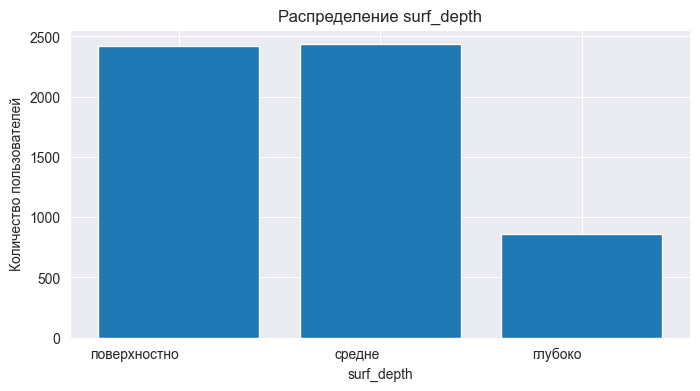

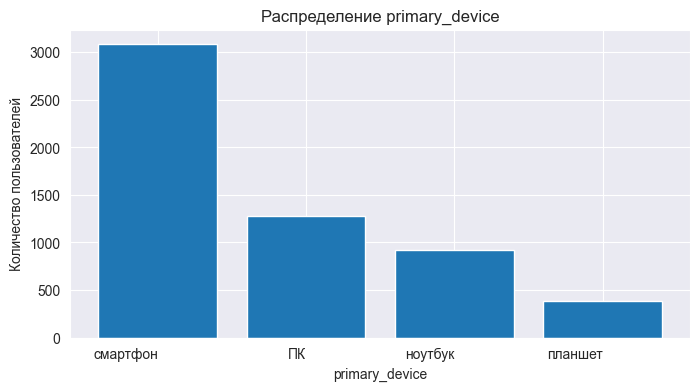

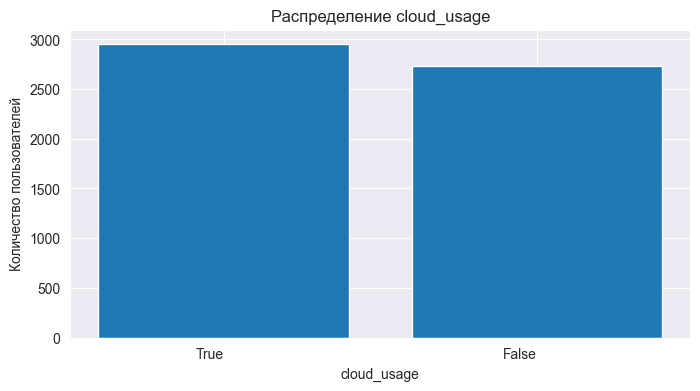

In [27]:
plot_cat_dist(surf_depth, "surf_depth", order=["поверхностно", "средне", "глубоко"], rotation=0)
plot_cat_dist(primary_device, "primary_device", rotation=0)
plot_cat_dist(cloud_usage, "cloud_usage", rotation=0)

Категориальные признаки из дополнительных источников распределены неравномерно: для `primary_device` доминирует **смартфон** (54%), в `surf_depth` категории **поверхностно** и **средне** встречаются примерно одинаково (42% каждая), а **глубоко** заметно реже (15%). Признак `cloud_usage` почти сбалансирован (True 52%, False 48%).


## Исследуем `visits`

In [28]:
#Общий осмотр visits
print(visits.dtypes)
print(visits.isnull().sum())
print(visits.columns)
display(visits.head(10))

In [29]:
# приводим data datetime
visits['date'] = pd.to_datetime(visits['date'], errors="coerce")

print("min date:", visits["date"].min())
print("max date:", visits["date"].max())
print("bad dates:", visits["date"].isna().sum())

In [30]:
visits['date'].value_counts()

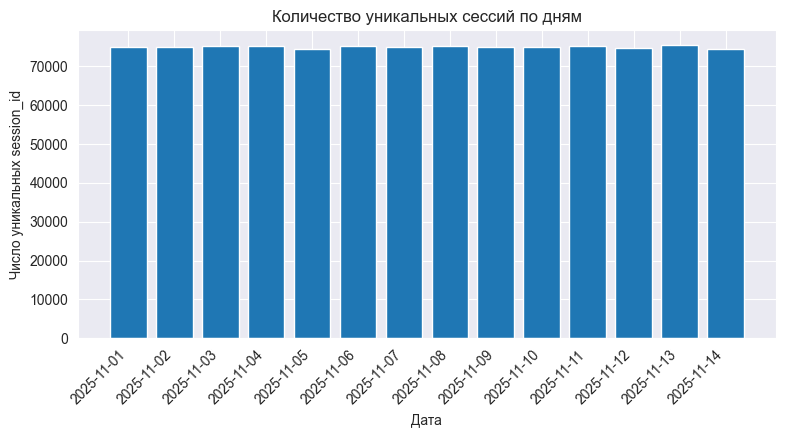

In [31]:
sessions_by_day = visits.groupby("date")["session_id"].nunique().sort_index()

plt.figure(figsize=(9,4))
plt.bar(sessions_by_day.index.astype(str), sessions_by_day.values)
plt.title("Количество уникальных сессий по дням")
plt.xlabel("Дата")
plt.ylabel("Число уникальных session_id")
plt.xticks(rotation=45, ha="right")
plt.show()

Количество уникальных сессий по дням в период 2025-11-01 - 2025-11-14 практически стабильно, существенных выбросов не наблюдается. Это снижает риск того, что модель будет "цепляться" за конкретные даты; в дальнейшем дату будем использовать преимущественно для агрегатов активности пользователя (число активных дней, интенсивность).

In [32]:
# Проверка уникальности целостности сессий
print("rows:", len(visits))
print("unique session_id:", visits["session_id"].nunique())
print("unique users:", visits["user_id"].nunique())

- Период логов: 2025-11-01 -> 2025-11-14, "битых" дат 0 -> данные корректно парсятся.
- `rows` = 1 065 745, `unique session_id` = 1 049 995 -> почти 1 строка = 1 сессия, но есть небольшая доля повторов `session_id` (примерно 15 750 строк "сверх" уникальных).
- `unique users` = 5826 -> в `visits` активности меньше, чем пользователей в `users`. Значит часть пользователей из users не имеет визитов и после объединения для них признаки из `visits` будут NaN/нули.


In [33]:
# Проверка на явные дубликаты
visits.duplicated().sum()

In [34]:
# Доля дубликатов по сессиям
dup_sessions = visits["session_id"].duplicated().sum()
print("duplicated session_id rows:", dup_sessions)
print("share:", dup_sessions / len(visits))

In [35]:
# Проверяем природу повторов
tmp = visits.groupby("session_id").agg(
    n_rows=("user_id", "size"),
    users=("user_id", "nunique"),
    dates=("date", "nunique"),
    daytimes=("daytime", "nunique"),
    cats=("website_category", "nunique")
)

tmp.describe()

In [36]:
# Смотрим самые длинные сессии
tmp.sort_values("n_rows", ascending=False).head(10)

In [37]:
# удаляем полные дубликаты
visits = visits.drop_duplicates().reset_index(drop=True)

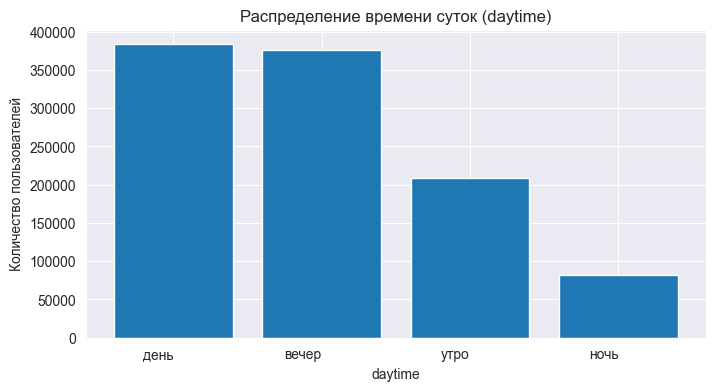

In [38]:
# Распределение по времени суток
plot_cat_dist(visits, "daytime", title="Распределение времени суток (daytime)", rotation=0)

Активность по времени суток распределена неравномерно: больше всего визитов приходится на день и вечер (36% и 36%), заметно меньше — на утро (20%), и минимум — на ночь (8%). Это подтверждает полезность признаков вида "доля активности пользователя по времени суток" и “наиболее активное время суток”.


In [39]:
# Распределение по категориям сайтов
print(visits["website_category"].nunique())
print(visits['website_category'].value_counts())

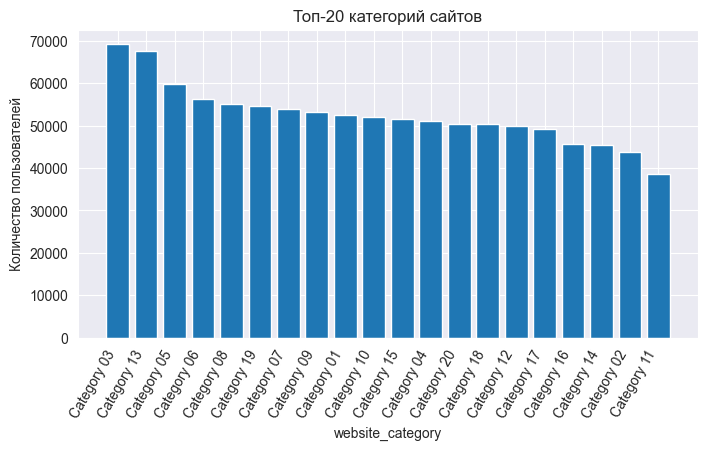

In [40]:
# Распределение по категоримя сайтов
plot_cat_dist(visits, "website_category", title="Топ-20 категорий сайтов", top_n=20, rotation=60)

В логах `visits` встречается 20 категорий сайтов (`website_category`). Распределение категорий относительно ровное: наиболее частые категории (например, `Category 03` и `Category 13`) занимают около 6–6.6% от всех записей, наименее частая - около 3.7%. Такая кардинальность и распределение позволяют безопасно использовать `one-hot` кодирование при построении признаков (например, в формате долей активности пользователя по категориям).

In [41]:
# Смотрим количество ссесий на пользователя
sessions_per_user = visits.groupby("user_id")["session_id"].nunique()

sessions_per_user.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

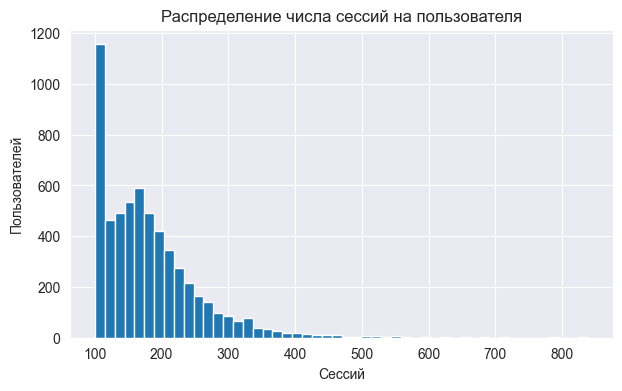

In [42]:
plt.figure(figsize=(7,4))
plt.hist(sessions_per_user, bins=50)
plt.title("Распределение числа сессий на пользователя")
plt.xlabel("Сессий")
plt.ylabel("Пользователей")
plt.show()

Число сессий на пользователя заметно варьируется: медиана - 167, среднее ~180, при этом распределение имеет правый "хвост" (99-й перцентиль ~439, максимум 839). Это означает, что признаки, связанные с интенсивностью активности (количество сессий, сессии в день), потенциально информативны, но могут иметь выбросы и широкий диапазон значений.


In [43]:
(sessions_per_user == sessions_per_user.min()).sum()

Минимальное число сессий на пользователя равно 100, и это значение встречается у 468 пользователей. Следовательно, это не единичный выброс, а, вероятно, нижняя граница/фильтр при формировании выборки активных пользователей.


## Корреляция

In [44]:
# доли по daytime (4 колонки)
daytime_share = (
    pd.crosstab(visits["user_id"], visits["daytime"], normalize="index")
    .add_prefix("daytime_share_")
    .reset_index()
)

# доли по website_category (20 колонок)
cat_share = (
    pd.crosstab(visits["user_id"], visits["website_category"], normalize="index")
    .add_prefix("cat_share_")
    .reset_index()
)

# базовые агрегаты
visits_eda = (
    visits.groupby("user_id")
    .agg(
        sessions_total=("session_id", "nunique"),
        active_days=("date", "nunique")
    )
    .reset_index()
)
visits_eda["sessions_per_day"] = visits_eda["sessions_total"] / visits_eda["active_days"]

# объединяем всё в одну витрину visits_eda_full
visits_eda_full = (
    visits_eda
    .merge(daytime_share, on="user_id", how="left")
    .merge(cat_share, on="user_id", how="left")
)

In [45]:
# объединение для EDA
ads_eda = ads_activity.drop_duplicates("user_id")

df_eda = (
    users
    .merge(visits_eda_full, on='user_id', how='left')
    .merge(ads_eda, on='user_id', how='left')
    .merge(surf_depth, on='user_id', how='left')
    .merge(primary_device, on='user_id', how='left')
    .merge(cloud_usage, on='user_id', how='left')
)

df_eda.shape, df_eda["user_id"].nunique()

In [46]:
display(df_eda.head(10))
print(df_eda.isna().sum().sum())
print(df_eda.isna().sum().sum() / len(df_eda))
print(df_eda.duplicated().sum())
print(df_eda.isna().sum())

In [47]:
rows_with_nan_share = df_eda.isna().any(axis=1).mean()
rows_with_nan_share

In [48]:
# Проверяем на выбросы новые признаки
df_eda[["sessions_total", "sessions_per_day", "active_days"]].describe(percentiles=[.5,.75,.9,.95,.99])

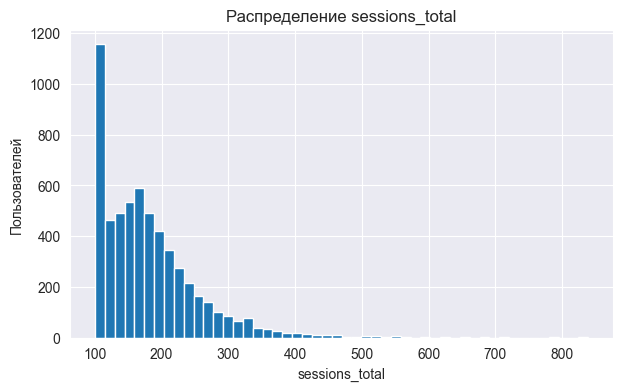

In [49]:
# Визуализация распределния sessions_total
plt.figure(figsize=(7,4))
plt.hist(df_eda["sessions_total"], bins=50)
plt.title("Распределение sessions_total")
plt.xlabel("sessions_total")
plt.ylabel("Пользователей")
plt.show()

Числовые признаки, полученные из `visits`, имеют разные распределения. `sessions_total` и `sessions_per_day` обладают правосторонним "хвостом": большинство пользователей имеют ~100–250 сессий за период, но встречаются значительно более активные (`max sessions_total` = 839). Признак `active_days` практически константный (в основном 14 дней), поэтому его вклад в модель вероятно будет минимальным, а `sessions_total` и `sessions_per_day` оказываются почти эквивалентными (мультиколлинеарность).


In [50]:
# Исключаем user_id
user_ids = df_eda["user_id"]
df_eda = df_eda.drop(columns=["user_id"])

После объединения таблиц пропуски встречаются примерно у 10.7% пользователей (есть хотя бы один NaN в признаках). Источник пропусков — неполное покрытие пользователей в дополнительных таблицах (`ads_activity`, `surf_depth`, `primary_device`, `cloud_usage`). Удалять такие наблюдения нецелесообразно, поэтому на этапе предобработки будем обрабатывать пропуски внутри пайплайна: для категориальных признаков - отдельная категория `unknown/most_frequent`, для булевого `cloud_usage` - заполнение наиболее логичным значением или отдельной категорией.

In [51]:
df_phik = df_eda.dropna().copy()
df_phik.shape

In [52]:
before = len(df_eda)
after = len(df_phik)
print(f"Осталось строк: {after} из {before} ({after/before:.2%})")

Для расчёта корреляций PhiK использовали только строки без пропусков (complete-case), чтобы исключить влияние NaN; при этом в анализе осталось 89% пользователей.

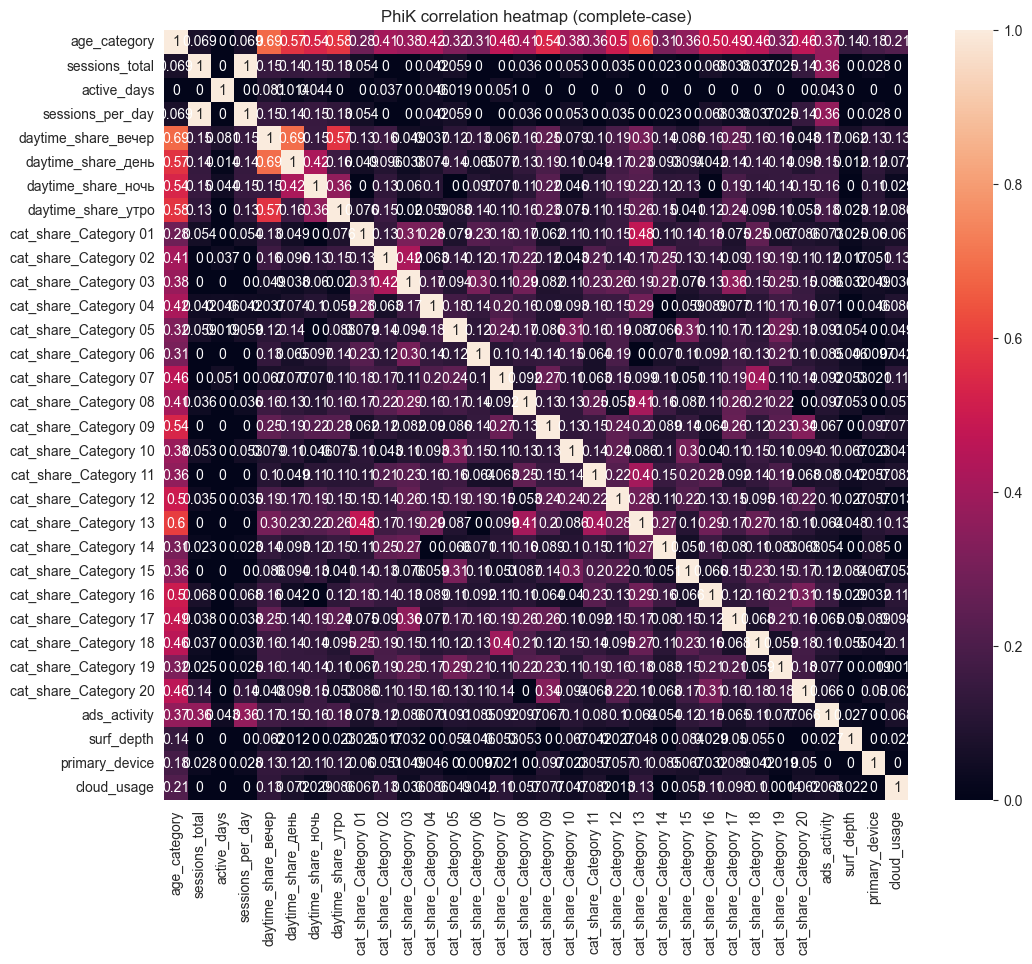

In [53]:
phik_corr = df_phik.phik_matrix()

plt.figure(figsize=(12,10))
sns.heatmap(phik_corr, annot=True)
plt.title("PhiK correlation heatmap (complete-case)")
plt.show()

phik_corr["age_category"].drop("age_category").sort_values(ascending=False).head(10)

In [54]:
phik_corr_rounded = phik_corr.round(3)
display(phik_corr_rounded)

In [55]:
target_corr = (
    phik_corr["age_category"]
    .drop("age_category")
    .sort_values(ascending=False)
)

display(target_corr.head(20).to_frame("phik"))

Для оценки зависимостей между признаками и целевой переменной рассчитали `PhiK`-корреляции на подмножестве строк без пропусков (`complete-case`: 5205 из 5826, 89.34%). Наибольшая связь с `age_category` наблюдается у поведенческих признаков из логов посещений: долей активности по времени суток (`daytime_share_*`, например `daytime_share_вечер`  0.69) и долей по категориям сайтов (`cat_share_*`, например `cat_share_Category 13`  0.60). Среди дополнительных источников заметную связь с целевой также показывают `ads_activity` (0.37), `cloud_usage` (0.21), `primary_device` (0.18) и `surf_depth` (0.14). Агрегаты общей активности (`sessions_total`, `sessions_per_day`) имеют более слабую связь (~0.07), а `active_days` практически неинформативен (PhiK 0), что объясняется почти одинаковым числом активных дней у пользователей в рассматриваемом периоде.


In [56]:
# Смотрим самую сильную корреляцию между признаками

mask = np.triu(np.ones(phik_corr.shape), k=1).astype(bool)

top_pairs = (
    phik_corr.where(mask)
             .stack()
             .sort_values(ascending=False)
             .head(15)
             .reset_index()
)

top_pairs.columns = ["feature_1", "feature_2", "phik"]
display(top_pairs)

Также обнаружена сильная зависимость между `sessions_total` и `sessions_per_day` (`PhiK~1`), поэтому далее имеет смысл оставить один из этих признаков.

In [57]:
# исключаем sessions_per_day
df_eda = df_eda.drop(columns=["sessions_per_day"])

### Выводы по EDA

- В ходе исследовательского анализа данных изучены все исходные таблицы и подготовлена витрина признаков на уровне пользователя (1 строка = 1 `user_id`).

- Целевая переменная `age_category` распределена неравномерно: самый частый класс - 56+ (30%), самый редкий — 18–25 (9%). Поэтому для оценки моделей далее будем использовать метрики с макро-усреднением (`F1_macro, precision_macro, recall_macro`), чтобы одинаково учитывать все возрастные группы.

- Качество и целостность данных.
    - В `users` были обнаружены дубликаты `user_id`, при этом конфликтов по `age_category` не выявлено - оставили по одной записи на пользователя.
    - В `visits` обнаружены полные дубликаты строк (~1.5%), которые не несут новой информации - такие дубликаты удалены, чтобы исключить двойной учёт активности.
    - Таблица `visits` содержит лог за период '2025-11-01' - '2025-11-14'. Количество уникальных сессий по дням распределено равномерно, явных "аномальных" дней не выявлено.

- Пропуски после объединения.
После объединения таблиц пропуски присутствуют примерно у 10–11% пользователей (как минимум в одном признаке). Источник пропусков - неполное покрытие пользователей в дополнительных таблицах (`ads_activity`, `surf_depth`, `primary_device`, `cloud_usage`). Удалять такие наблюдения нецелесообразно, поэтому на этапе предобработки пропуски будут обрабатываться внутри пайплайна (без утечек): для категориальных признаков — заполнение отдельной категорией `unknown`/`most_frequent`, для `cloud_usage` - заполнение наиболее логичным значением или выделение отдельной категории.

- Поведение пользователей в `visits`.
    - Активность по времени суток распределена неравномерно: больше всего визитов приходится на день и вечер (~36% и ~36%), меньше - на утро (~20%), минимум - на ночь (~8%).
    - Общее число сессий на пользователя (`sessions_total`) имеет правосторонний "хвост": большинство пользователей находятся в диапазоне ~100–250 сессий за период, но встречаются значительно более активные (max ~ 839).

- Зависимости признаков и отбор.
`PhiK`-корреляции показывают, что наибольшая связь с возрастной категорией наблюдается у поведенческих признаков из логов посещений (доли активности по времени суток `daytime_share_*` и по категориям сайтов `cat_share_*`). Среди дополнительных источников заметную связь с целевой переменной также показывают `ads_activity`, `cloud_usage`, `primary_device`, `surf_depth`.
Дополнительно выявлена сильная зависимость между `sessions_total` и `sessions_per_day` (высокая мультиколлинеарность, т.к. `active_days` почти постоянен).

Итог: данные очищены от явных дубликатов, собрана пользовательская витрина признаков и сформулированы решения по обработке пропусков и мультиколлинеарности. Можно переходить к этапу предобработки и построения базовых моделей.


## Предобработка

In [58]:
# Делим на выборки

X = df_eda.drop(columns=['age_category'])
y = df_eda['age_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)

In [59]:
print(X_train.shape, X_test.shape)

Поскольку витрина сформирована на уровне пользователя (1 строка = 1 user_id), разбиение на train/test выполняем по строкам со стратификацией по целевому признаку. Условие отсутствия пересечений пользователей между выборками выполняется.

In [60]:
# Приводим колонки cloud_usage к 0/1
for df_ in (X_train, X_test):
    df_['cloud_usage'] = df_['cloud_usage'].fillna(False).astype(int)

# формируем списки признаков для дальнейшей предобработки
cat_features = ["ads_activity", "surf_depth", "primary_device"]
num_features = [c for c in X_train.columns if c not in cat_features]
print("Категориальные:", cat_features)
print("Числовые:", len(num_features))

In [61]:
# Собираем ColumnTransformer
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, num_features),
    ('cat', categorical_pipe, cat_features)
])

## Обучение и оценка базовой модели

In [62]:
# задаём CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# формируем словарь основных метрик
scoring = {
    "f1_macro": make_scorer(f1_score, average='macro'),
    "precision_macro": make_scorer(precision_score, average='macro', zero_division=0),
    "recall_macro": make_scorer(recall_score, average='macro', zero_division=0)
}

In [63]:
# Baseline - DummyClassifier
dummy_clf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE))
])

dummy_cv = cross_validate(dummy_clf, X_train, y_train, cv=cv, scoring=scoring)
{k: dummy_cv["test_"+k].mean() for k in scoring}

In [64]:
# Baseline 2: LogisticRegression (multinomial)
logreg_clf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        solver="lbfgs",
        max_iter=4000,
        random_state=RANDOM_STATE
    ))
])

logreg_cv = cross_validate(logreg_clf, X_train, y_train, cv=cv, scoring=scoring)
{k: logreg_cv["test_"+k].mean() for k in scoring}

In [65]:
# Baseline 3: SVC

svc_clf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(kernel='linear' ,random_state=RANDOM_STATE))
])

svc_linear_cv = cross_validate(svc_clf, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
{k: svc_linear_cv["test_"+k].mean() for k in scoring}

In [66]:
# Строим таблицу сравнения базовых моделей
baseline_results = pd.DataFrame([
    {
        "model": "Dummy(most_frequent)",
        "f1_macro": dummy_cv["test_f1_macro"].mean(),
        "precision_macro": dummy_cv["test_precision_macro"].mean(),
        "recall_macro": dummy_cv["test_recall_macro"].mean(),
    },
    {
        "model": "LogReg(multinomial)",
        "f1_macro": logreg_cv["test_f1_macro"].mean(),
        "precision_macro": logreg_cv["test_precision_macro"].mean(),
        "recall_macro": logreg_cv["test_recall_macro"].mean(),
    },
    {
        "model": "SVC(linear)",
        "f1_macro": svc_linear_cv["test_f1_macro"].mean(),
        "precision_macro": svc_linear_cv["test_precision_macro"].mean(),
        "recall_macro": svc_linear_cv["test_recall_macro"].mean()
    }
]).sort_values("f1_macro", ascending=False)
baseline_results

В качестве базовой линии использовали `DummyClassifier(strategy="most_frequent")`, который показал ожидаемо низкое качество: `F1_macro` ~ 0.093 (модель фактически предсказывает самый частый класс и игнорирует признаки).

Далее были обучены две базовые модели с пайплайном предобработки и оценены на `5-fold StratifiedKFold` (`macro`-метрики):
- LogisticRegression показала `F1_macro` ~ 0.816, precision_macro ~ 0.823, `recall_macro` ~ 0.811;
- SVC(kernel='linear') оказалась лучшей среди `baseline`-моделей: `F1_macro` ~ 0.825, `precision_macro` ~ 0.827, `recall_macro` ~ 0.825.

Таким образом, обе модели существенно превосходят `baseline` `Dummy` и выполняют требование проекта `F1_macro` ≥ 0.75 на кросс-валидации, а наилучший результат среди линейных `baseline` демонстрирует `SVC` с линейным ядром, поэтому именно её и `LogisticRegression` далее использовали для экспериментов с признаками и подбора гиперпараметров.

## Создание и отбор признаков

In [67]:
# Задаём функцию для генирации признаков
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # log-преобразование
    if 'sessions_total' in df.columns:
        df["log_sessions_total"] = np.log1p(df["sessions_total"])

    # колонки долей
    day_cols = [c for c in df.columns if c.startswith("daytime_share_")]
    cat_cols = [c for c in df.columns if c.startswith("cat_share_Category")]

    if day_cols:
        df["dominant_daytime_share"] = df[day_cols].max(axis=1)
        df["unique_daytimes"] = (df[day_cols] > 0).sum(axis=1)

        # вечер/ночь и утро/день
        if "daytime_share_вечер" in df.columns and "daytime_share_ночь" in df.columns:
            df["late_share"] = df["daytime_share_вечер"] + df["daytime_share_ночь"]
        if "daytime_share_утро" in df.columns and "daytime_share_день" in df.columns:
            df["work_share"] = df["daytime_share_утро"] + df["daytime_share_день"]

    if cat_cols:
        df["dominant_category_share"] = df[cat_cols].max(axis=1)
        df["unique_categories"] = (df[cat_cols] > 0).sum(axis=1)

    return df

feature_adder = FunctionTransformer(add_features, validate=False)

In [68]:
# Формируем pipeline
feature_adder = FunctionTransformer(add_features, validate=False)

preprocessor_auto = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, selector(dtype_include=np.number)),
        ("cat", categorical_pipe, selector(dtype_include=object)),
    ],
    remainder="drop"
)

logreg_clf_add = Pipeline([
    ("feature_adder", feature_adder),
    ("preprocessor", preprocessor_auto),
    ("model", LogisticRegression(solver="lbfgs", max_iter=4000, random_state=RANDOM_STATE))
])

svc_clf_add = Pipeline([
    ("feature_adder", feature_adder),
    ("preprocessor", preprocessor_auto),
    ("model", SVC(kernel='linear', random_state=RANDOM_STATE))
])

add_cv_lr = cross_validate(logreg_clf_add, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
svc_cv_add = cross_validate(svc_clf_add, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

res_add = pd.DataFrame([
    {
        "model": "LogReg(multinomial)",
        "f1_macro": logreg_cv["test_f1_macro"].mean(),
        "precision_macro": logreg_cv["test_precision_macro"].mean(),
        "recall_macro": logreg_cv["test_recall_macro"].mean(),
    },
    {
        "model": "LogReg + new features",
        "f1_macro": add_cv_lr["test_f1_macro"].mean(),
        "precision_macro": add_cv_lr["test_precision_macro"].mean(),
        "recall_macro": add_cv_lr["test_recall_macro"].mean(),
    },
    {
        "model": "SVC(linear)",
        "f1_macro": svc_linear_cv["test_f1_macro"].mean(),
        "precision_macro": svc_linear_cv["test_precision_macro"].mean(),
        "recall_macro": svc_linear_cv["test_recall_macro"].mean()
    },
    {
        "model": "SVC(linear)+new features",
        "f1_macro": svc_cv_add["test_f1_macro"].mean(),
        "precision_macro": svc_cv_add["test_precision_macro"].mean(),
        "recall_macro": svc_cv_add["test_recall_macro"].mean()
    }
]).sort_values("f1_macro", ascending=False)

res_add


In [69]:
# Фильтрация по Threshold lr
pipe_var_add_lr = Pipeline([
    ("feature_adder", feature_adder),
    ("preprocessor", preprocessor_auto),
    ("var", VarianceThreshold(threshold=0.0)),
    ("model", LogisticRegression(solver="lbfgs", max_iter=4000, random_state=RANDOM_STATE))
])

var_cv = cross_validate(pipe_var_add_lr, X_train, y_train, cv=cv, scoring=scoring)
{k: var_cv["test_"+k].mean() for k in scoring}

In [70]:
# Фильтрация по Threshold SVC
pipe_var_add_svc = Pipeline([
    ("feature_adder", feature_adder),
    ("preprocessor", preprocessor_auto),
    ("var", VarianceThreshold(threshold=0.0)),
    ("model", SVC(kernel='linear', random_state=RANDOM_STATE))
])

svc_add_var_cv = cross_validate(pipe_var_add_svc, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
{k: svc_add_var_cv["test_"+k].mean() for k in scoring}

In [71]:
# RFE lr
selector_lr = RFECV(
    estimator=LogisticRegression(solver="lbfgs", max_iter=4000, random_state=RANDOM_STATE),
    step=1,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

pipe_rfecv_lr = Pipeline([
    ("feature_adder", feature_adder),
    ('preprocessor', preprocessor_auto),
    ("var", VarianceThreshold(threshold=0.0)),
    ('rfecv', selector_lr),
    ('model', LogisticRegression(solver="lbfgs", max_iter=4000, random_state=RANDOM_STATE)),
])

rfecv_cv_lr = cross_validate(pipe_rfecv_lr, X_train, y_train, cv=cv, scoring=scoring)
{k: rfecv_cv_lr["test_"+k].mean() for k in scoring}

In [72]:
# RFE SVC
selector_svc = RFECV(
    estimator=SVC(kernel='linear', random_state=RANDOM_STATE),
    step=1,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

pipe_rfecv_svc = Pipeline([
    ("feature_adder", feature_adder),
    ("preprocessor", preprocessor_auto),
    ("var", VarianceThreshold(threshold=0.0)),
    ("rfecv", selector_svc),
    ("model", SVC(kernel='linear', random_state=RANDOM_STATE))
])

svc_add_rfecv_cv = cross_validate(pipe_rfecv_svc, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
{k: svc_add_rfecv_cv["test_"+k].mean() for k in scoring}

In [73]:
# роверка для чествности сравнения
svc_clf_auto = Pipeline([
    ("preprocessor", preprocessor_auto),
    ("model", SVC(kernel="linear"))
])
svc_auto_cv = cross_validate(svc_clf_auto, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
{k: svc_auto_cv["test_"+k].mean() for k in scoring}

Для проверки корректности сравнения дополнительно оценили SVC(kernel="linear") с preprocessor_auto. Качество совпало с вариантом на ручном препроцессоре (F1_macro ~ 0.825), поэтому далее используем preprocessor_auto как более универсальный и устойчивый к изменениям витрины.


После добавления новых признаков качество `LogReg` выросло до `F1_macro` ~ 0.8187. Дополнительно протестировали отбор признаков с `VarianceThreshold` и `RFECV`: качество осталось на сопоставимом уровне и не ухудшилось; в лучшей конфигурации (`feature engineering` + фильтрация + `RFECV`) получено `f1_macro` ~ 0.8188. Прирост относительно варианта без отбора минимален, поэтому далее будем ориентироваться на более простую конфигурацию (`feature engineering` + `LogReg`), а отбор рассматриваем как дополнительный шаг для потенциального уменьшения размерности.

Для SVC в качестве baseline была оценена модель `SVC(kernel='linear')` с тем же пайплайном предобработки, которая показала более высокое качество на кросс-валидации: `F1_macro` ~ 0.8253. Попытка улучшить линейный `SVC` за счёт добавления новых признаков и отбора (`VarianceThreshold` + `RFECV`) не привела к росту качества: метрика снизилась до `F1_macro` ~ 0.8200, что указывает на то, что для линейного `SVC` исходное признаковое пространство уже достаточно информативно, а дополнительная селекция/инженерия в данном виде скорее удаляет полезные слабые сигналы.

Таким образом, среди линейных моделей на данном этапе лидирует `SVC(kernel='linear')`, а дальнейший прирост качества ожидается от подбора гиперпараметров и проверки нелинейных ядер (например, `RBF`) на шаге `GridSearchCV`.

## Подбор гиперпараметров моделей

In [74]:
# GridSearchCV для LogisticRegression
f1_macro = make_scorer(f1_score, average='macro')

param_grid_lr = {
    "model__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10],
    "model__class_weight": [None, "balanced"],
}

gs_lr = GridSearchCV(
    logreg_clf_add,
    param_grid=param_grid_lr,
    cv=cv,
    n_jobs=-1,
    scoring=scoring,
    refit='f1_macro',
    return_train_score=False
)

gs_lr.fit(X_train, y_train)
print("LR best params:", gs_lr.best_params_)
print("LR best f1_macro:", gs_lr.best_score_)

lr_res = pd.DataFrame(gs_lr.cv_results_)
cols = ["rank_test_f1_macro", "mean_test_f1_macro", "mean_test_precision_macro",
        "mean_test_recall_macro", "std_test_f1_macro", "params"]
lr_res[cols].sort_values("rank_test_f1_macro").head(10)

In [75]:
# GridSearchCV для SVC (linear + rbf)
svc_pipe = Pipeline([
    ("preprocessor", preprocessor_auto),
    ("model", SVC())
])

param_grid_svc = [
    {"model__kernel": ["linear"], "model__C": [0.1, 0.3, 1, 3, 10, 30]},
    {"model__kernel": ["rbf"], "model__C": [0.1, 0.3, 1, 3, 10, 30], "model__gamma": ["scale", "auto"]},
]

gs_svc = GridSearchCV(
    svc_pipe,
    param_grid=param_grid_svc,
    cv=cv,
    scoring=scoring,
    refit='f1_macro',
    n_jobs=-1,
    return_train_score=False
)

gs_svc.fit(X_train, y_train)

print("SVC best params:", gs_svc.best_params_)
print("SVC best f1_macro:", gs_svc.best_score_)

svc_res = pd.DataFrame(gs_svc.cv_results_)
cols = ["rank_test_f1_macro", "mean_test_f1_macro", "mean_test_precision_macro",
        "mean_test_recall_macro", "std_test_f1_macro", "params"]
svc_res[cols].sort_values("rank_test_f1_macro").head(10)

Подбор гиперпараметров показал, что для LogisticRegression оптимальными остаются C=1 и class_weight=None (F1_macro ~ 0.819 на CV).
Для SVC наилучшей оказалась конфигурация с RBF-ядром (C=1, gamma='scale'), которая значительно улучшила качество до F1_macro ~ 0.903 на CV. Это указывает на наличие нелинейных зависимостей в данных поведения пользователей. В качестве финальной модели выбираем SVC(RBF) и оцениваем её на тестовой выборке один раз.

## Финальное обучение и проверка

In [76]:
best_svc = gs_svc.best_estimator_
best_svc.fit(X_train, y_train)

y_pred = best_svc.predict(X_test)
print("TEST F1_macro:", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred, digits=3))

In [77]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=sorted(y_test.unique()), columns=sorted(y_test.unique()))
cm_df

По результатам подбора гиперпараметров (GridSearchCV, StratifiedKFold(n_splits=5, shuffle=True, random_state=42), основная метрика - F1_macro) лучшей моделью оказалась SVC с RBF-ядром (kernel='rbf', C=1, gamma='scale'). На кросс-валидации модель показала F1_macro ~ 0.903, что существенно выше линейных базовых моделей.

Далее модель была обучена на всей обучающей выборке и единожды оценена на тестовой. Итоговое качество на тесте составило F1_macro = 0.889, что превышает требование проекта (>= 0.75). По классовым метрикам лучшая точность достигается для старших возрастных групп 41–55 и 56+ (F1 ≈ 0.913 и 0.944 соответственно). Наиболее сложной для классификации оказалась категория 18–25 (F1 ≈ 0.813): основная часть ошибок приходится на путаницу с соседними группами (<18 и 26–40), что соответствует естественной близости возрастных категорий по поведенческим паттернам.

Таким образом, финальный пайплайн предобработки и модели обеспечивает стабильное высокое качество классификации возраста по цифровому следу и может быть рекомендован к внедрению.

## Подготовка артефактов модели для внедрения

In [78]:
# --- 1) Функция сборки витрины (сырьё -> X, y, user_id) ---
def build_features(users, visits, ads_activity, surf_depth, primary_device, cloud_usage):
    users = users.drop_duplicates("user_id").copy()
    v = visits.drop_duplicates().copy()

    visits_agg = (v.groupby("user_id")
        .agg(
            sessions_total=("session_id", "nunique"),
            active_days=("date", "nunique"),
        )
        .reset_index()
    )

    daytime_share = (
        pd.crosstab(v["user_id"], v["daytime"], normalize="index")
        .add_prefix("daytime_share_")
        .reset_index()
    )

    cat_share = (
        pd.crosstab(v["user_id"], v["website_category"], normalize="index")
        .add_prefix("cat_share_")
        .reset_index()
    )

    visits_features = (visits_agg
        .merge(daytime_share, on="user_id", how="left")
        .merge(cat_share, on="user_id", how="left")
    )

    ads_activity = ads_activity.drop_duplicates("user_id")
    surf_depth = surf_depth.drop_duplicates("user_id")
    primary_device = primary_device.drop_duplicates("user_id")
    cloud_usage = cloud_usage.drop_duplicates("user_id")

    df = (users
        .merge(visits_features, on="user_id", how="left")
        .merge(ads_activity, on="user_id", how="left")
        .merge(surf_depth, on="user_id", how="left")
        .merge(primary_device, on="user_id", how="left")
        .merge(cloud_usage, on="user_id", how="left")
    )

    # user_id сохраняем отдельно (полезно для продакшена/дебага)
    user_id = df["user_id"].copy() if "user_id" in df.columns else None

    # y возвращаем только если он есть (в продакшене его не будет)
    y = df["age_category"].copy() if "age_category" in df.columns else None

    # X — всё кроме идентификатора и таргета
    drop_cols = [c for c in ["user_id", "age_category"] if c in df.columns]
    X = df.drop(columns=drop_cols)

    return X, y, user_id

In [79]:
# сохранение артефактов
joblib.dump(best_svc, "final_svc_pipeline.joblib")

# --- 3) Сохраняем функцию сборки витрины в отдельный .py файл ---
feature_builder_code = r'''
import pandas as pd

def build_features(users, visits, ads_activity, surf_depth, primary_device, cloud_usage):
    users = users.drop_duplicates("user_id").copy()
    v = visits.drop_duplicates().copy()

    visits_agg = (v.groupby("user_id")
        .agg(
            sessions_total=("session_id", "nunique"),
            active_days=("date", "nunique"),
        )
        .reset_index()
    )

    daytime_share = (
        pd.crosstab(v["user_id"], v["daytime"], normalize="index")
          .add_prefix("daytime_share_")
          .reset_index()
    )

    cat_share = (
        pd.crosstab(v["user_id"], v["website_category"], normalize="index")
          .add_prefix("cat_share_")
          .reset_index()
    )

    visits_features = (visits_agg
        .merge(daytime_share, on="user_id", how="left")
        .merge(cat_share, on="user_id", how="left")
    )

    ads_activity = ads_activity.drop_duplicates("user_id")
    surf_depth = surf_depth.drop_duplicates("user_id")
    primary_device = primary_device.drop_duplicates("user_id")
    cloud_usage = cloud_usage.drop_duplicates("user_id")

    df = (users
        .merge(visits_features, on="user_id", how="left")
        .merge(ads_activity, on="user_id", how="left")
        .merge(surf_depth, on="user_id", how="left")
        .merge(primary_device, on="user_id", how="left")
        .merge(cloud_usage, on="user_id", how="left")
    )

    user_id = df["user_id"].copy() if "user_id" in df.columns else None
    y = df["age_category"].copy() if "age_category" in df.columns else None
    X = df.drop(columns=[c for c in ["user_id", "age_category"] if c in df.columns])

    return X, y, user_id
'''

with open("feature_builder.py", "w", encoding="utf-8") as f:
    f.write(feature_builder_code)

loaded_model = joblib.load("final_svc_pipeline.joblib")
pred_loaded = loaded_model.predict(X_test)

print("Predictions equal:", np.array_equal(y_pred, pred_loaded))

# Проверяем полный продакшен-пайплайн: сырые таблицы -> build_features -> model
from feature_builder import build_features as build_features_loaded

X_full, y_full, user_id_full = build_features_loaded(
    users, visits, ads_activity, surf_depth, primary_device, cloud_usage
)

pred_full = loaded_model.predict(X_full)

print("Feature builder output shape:", X_full.shape)
print("Example predictions:", pred_full[:5])

Итоговый пайплайн сохранён в файл final_svc_pipeline.joblib. После загрузки артефакта предсказания на тестовой выборке полностью совпали с исходными (Predictions equal: True), что подтверждает корректность сохранения и воспроизводимость решения.

Сохранён единый пайплайн, включающий предобработку признаков и обученную модель SVC.

## Вывод по проекту

#### Постановка задачи

В рамках проекта для компании **Йети** была решена задача многоклассовой классификации возраста пользователей по их цифровому следу. Требовалось предсказать `age_category` (0:<18, 1:18–25, 2:26–40, 3:41–55, 4:56+) по логам посещений и дополнительным источникам. Основная метрика качества - `F1_macro` (с учётом дисбаланса классов), целевой порог - `F1_macro` >= 0.75 на `CV` и `test`.

#### Данные и сбор витрины

Исходные данные были представлены в нескольких таблицах (`users`, `visits`, `ads_activity`, `surf_depth`, `primary_device`, `cloud_usage`).
Для моделирования построена единая витрина признаков на уровне пользователя (1 строка = 1 `user_id`):
   - из `visits` агрегированы пользовательские признаки: общее число сессий (`sessions_total`), число активных дней, доли активности по времени суток (daytime_share_*) и по категориям сайтов (`cat_share_*`);
   - из дополнительных таблиц добавлены категориальные и булевы признаки: `ads_activity`, `surf_depth`, `primary_device`, `cloud_usage`.

После объединения выявлено неполное покрытие пользователей в дополнительных источниках: примерно у 10–11% пользователей присутствуют пропуски хотя бы в одном из дополнительных признаков. Эти пропуски не удалялись — они обрабатывались в пайплайне предобработки (импутация), чтобы не терять данные.

#### EDA и ключевые наблюдения
   - Целевая переменная `age_category` распределена неравномерно -> для корректной оценки использовались `macro`-метрики (`F1_macro`, `precision_macro`, `recall_macro`).
   - Активность по времени суток и по категориям сайтов показала различимый поведенческий профиль, что подтверждено анализом распределений и оценкой зависимостей (`PhiK`/визуализации).
   - Для числовых агрегатов (`sessions_total`) обнаружено правостороннее распределение (хвост активности), что учитывалось в дальнейших экспериментах (в т.ч. проверялись лог-преобразования).

#### Предобработка

- Для предотвращения утечек вся предобработка была реализована внутри `Pipeline` + `ColumnTransformer`:
   - числовые признаки: `SimpleImputer(median)` + `StandardScaler`
   - категориальные: `SimpleImputer(most_frequent)` + `OneHotEncoder(handle_unknown='ignore')`
   - `cloud_usage` приведён к 0/1

- Разбиение на `train`/`test` выполнено со стратификацией по целевой переменной, фиксирован `RANDOM_STATE`, применялась `StratifiedKFold` на `CV`.

#### `Baseline`-модели

В качестве `baseline` был использован `DummyClassifier(most_frequent)`, показавший низкое качество (`F1_macro` ~ 0.093).
Линейная модель `LogisticRegression` с пайплайном предобработки дала существенный прирост (`F1_macro` ~ 0.816 на `CV`), превысив требуемый порог качества.

#### Улучшение признаков и отбор

Были протестированы дополнительные производные признаки (`feature engineering`) внутри пайплайна (`FunctionTransformer`), а также методы отбора (`VarianceThreshold`, `RFECV`). Улучшение для `LogisticRegression` оказалось небольшим, что подтвердило, что базовая витрина уже достаточно информативна.

#### Подбор гиперпараметров и выбор финальной модели

Для `LogisticRegression` проведён `GridSearchCV` по `C` и `class_weight`, значимого улучшения сверх ~0.819 не получено.
Для `SVC` проведён `GridSearchCV` по `kernel`, `C` и `gamma`. Лучшая конфигурация - `SVC` с `RBF`-ядром `(kernel='rbf', C=1, gamma='scale')`, показавшая высокое качество на `CV` `(F1_macro ≈ 0.903)`. Это указывает на наличие нелинейных зависимостей в данных поведения пользователей.

#### Финальная оценка на тесте

Лучшая модель обучена на всей обучающей выборке и единожды оценена на тестовой:
   - `TEST F1_macro` = **0.889** (требование >= 0.75 выполнено с запасом)
   - Наиболее сложным классом оказалась категория 18–25, ошибки в основном происходят между соседними возрастными группами, что естественно для возрастных интервалов.

#### Подготовка артефактов и проверка воспроизводимости

Итоговый пайплайн (предобработка + модель) сохранён в файл `final_svc_pipeline.joblib`. После загрузки артефакта предсказания на тестовой выборке полностью совпали с исходными (`Predictions equal: True`), что подтверждает корректность сохранения и воспроизводимость решения.

--------------

### Рекомендации
1.	Контроль ошибок для несовершеннолетних
Так как бизнес-риски связаны с неверной классификацией несовершеннолетних, рекомендуется дополнительно мониторить ошибки вида 0→1/2/3/4 (переоценка возраста). При необходимости можно вводить “осторожную” стратегию: повышать порог уверенности для перевода пользователя из 0 в более старшие классы.
2. Улучшение качества для класса 18–25
Класс 18–25 оказался наиболее сложным. Возможные пути улучшения:

    - добавить дополнительные поведенческие признаки (например, агрегаты разнообразия/энтропии на уровне пользователя, более детальные поведенческие метрики);
    - использовать дополнительные источники (частота взаимодействий с рекламой, типы контента, долгосрочная история);
    - рассмотреть ансамблевые модели (если допустимо) или расширенный поиск гиперпараметров `SVC`.

3.	Мониторинг качества в продакшене
После внедрения важно настроить мониторинг:

  - распределения предсказанных классов во времени;
  - drift признаков (доли по категориям сайтов и времени суток);
  - контроль качества на размеченной выборке (по мере накопления).

------------

#### Решение по внедрению

Модель рекомендуется к внедрению, так как:
   - достигнут высокий уровень качества на тестовой выборке (`F1_macro = 0.889);
   - выполняются требования проекта по отсутствию утечек и воспроизводимости;
   - подготовлены и проверены артефакты (сохранён полный пайплайн предобработки + модель).
